In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from prompt_toolkit.key_binding.bindings.named_commands import end_of_line
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sympy.stats import std
from xgboost import XGBRegressor
from scipy.stats import iqr, skew, kurtosis

In [2]:
COLS = ["Unit", "Cycle", "Os1", "Os2", "Os3"] + [f"Sens_{i}" for i in range(21)]
COLS

['Unit',
 'Cycle',
 'Os1',
 'Os2',
 'Os3',
 'Sens_0',
 'Sens_1',
 'Sens_2',
 'Sens_3',
 'Sens_4',
 'Sens_5',
 'Sens_6',
 'Sens_7',
 'Sens_8',
 'Sens_9',
 'Sens_10',
 'Sens_11',
 'Sens_12',
 'Sens_13',
 'Sens_14',
 'Sens_15',
 'Sens_16',
 'Sens_17',
 'Sens_18',
 'Sens_19',
 'Sens_20']

In [3]:
train_01 = pl.read_csv(
    "../CMAPSSData/train_FD001.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    columns=range(26),
    new_columns=COLS
)

In [4]:
train_01.head(), train_01.shape


(shape: (5, 26)
 ┌──────┬───────┬─────────┬─────────┬───┬─────────┬─────────┬─────────┬─────────┐
 │ Unit ┆ Cycle ┆ Os1     ┆ Os2     ┆ … ┆ Sens_17 ┆ Sens_18 ┆ Sens_19 ┆ Sens_20 │
 │ ---  ┆ ---   ┆ ---     ┆ ---     ┆   ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
 │ i64  ┆ i64   ┆ f64     ┆ f64     ┆   ┆ i64     ┆ f64     ┆ f64     ┆ f64     │
 ╞══════╪═══════╪═════════╪═════════╪═══╪═════════╪═════════╪═════════╪═════════╡
 │ 1    ┆ 1     ┆ -0.0007 ┆ -0.0004 ┆ … ┆ 2388    ┆ 100.0   ┆ 39.06   ┆ 23.419  │
 │ 1    ┆ 2     ┆ 0.0019  ┆ -0.0003 ┆ … ┆ 2388    ┆ 100.0   ┆ 39.0    ┆ 23.4236 │
 │ 1    ┆ 3     ┆ -0.0043 ┆ 0.0003  ┆ … ┆ 2388    ┆ 100.0   ┆ 38.95   ┆ 23.3442 │
 │ 1    ┆ 4     ┆ 0.0007  ┆ 0.0     ┆ … ┆ 2388    ┆ 100.0   ┆ 38.88   ┆ 23.3739 │
 │ 1    ┆ 5     ┆ -0.0019 ┆ -0.0002 ┆ … ┆ 2388    ┆ 100.0   ┆ 38.9    ┆ 23.4044 │
 └──────┴───────┴─────────┴─────────┴───┴─────────┴─────────┴─────────┴─────────┘,
 (20631, 26))

In [5]:
for col in train_01.columns:
    print(col, train_01[col].n_unique())

Unit 100
Cycle 362
Os1 158
Os2 13
Os3 1
Sens_0 1
Sens_1 310
Sens_2 3012
Sens_3 4051
Sens_4 1
Sens_5 2
Sens_6 513
Sens_7 53
Sens_8 6403
Sens_9 1
Sens_10 159
Sens_11 427
Sens_12 56
Sens_13 6078
Sens_14 1918
Sens_15 1
Sens_16 13
Sens_17 1
Sens_18 1
Sens_19 120
Sens_20 4745


AS there is a lot of columns with only 1 unique entry it is a good habit to check what is the situtation like for all of the res training data

In [6]:
lazy_df = pl.scan_csv(
    f"../CMAPSSData/train_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    new_columns=COLS,
    include_file_paths="file_path"
 )

In [7]:
processed_lazy_df = lazy_df.with_columns( #Calculating target variable for all training data
    (pl.col("Cycle").max().over(["file_path", "Unit"]) - pl.col("Cycle")).alias("RUL")
).drop(["column_27", "column_28"])#"file_path"

df = processed_lazy_df.collect()

 I want to divide RUL column into three categories i.e. small, medium and large amount of left to be able to compare some of the unique values of features efficently

<Axes: ylabel='Count'>

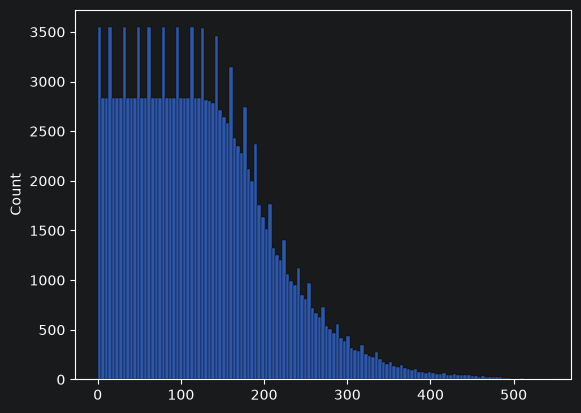

In [8]:
sns.histplot(df["RUL"])

In [9]:
df["RUL"].value_counts(sort=True)

RUL,count
i64,u32
127,709
126,709
125,709
124,709
123,709
…,…
529,1
528,1
527,1


Using 80/20 rule (which is used as the engine is a costly thing to replace/maintain and 80/20 rule is used in cost optimazation). The cut off number is 20% of max cycles for all engines (127).

In [10]:
lower_bound = math.ceil(127 * 0.2)
lower_bound

26

In [11]:
df_aux = df.with_columns(
    pl.col("RUL").log().alias("RUL_log")
)

<Axes: ylabel='Count'>

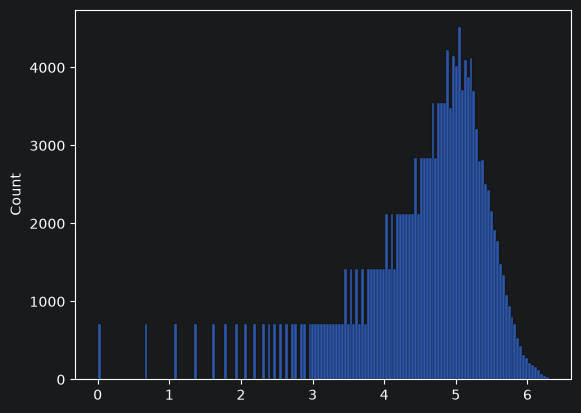

In [12]:
sns.histplot(df_aux["RUL_log"])


Here as an upper bound the beginning of the right slope will be used so that is about 5.2

In [13]:
upper_bound = math.floor(math.e ** 5.2)
upper_bound

181

In [14]:
#Create categorical target variable to be later used with seaborn's hue
df = df.with_columns(
    pl.when(pl.col("RUL") < lower_bound)
    .then(pl.lit("high exploitation"))
    .when(pl.col("RUL") > upper_bound)
    .then(pl.lit("None exploitation"))
    .otherwise(pl.lit("Normal exploitation"))
    .alias("exploitation_status")
)


In [15]:
df["exploitation_status"].value_counts()

exploitation_status,count
str,u32
"""Normal exploitation""",106854
"""None exploitation""",35071
"""high exploitation""",18434


In [16]:
for col in df.columns:
    print(col, df[col].n_unique())

Unit 260
Cycle 543
Os1 670
Os2 111
Os3 2
Sens_0 6
Sens_1 1799
Sens_2 15377
Sens_3 20582
Sens_4 6
Sens_5 56
Sens_6 6311
Sens_7 1163
Sens_8 34161
Sens_9 21
Sens_10 771
Sens_11 5982
Sens_12 567
Sens_13 20090
Sens_14 13124
Sens_15 2
Sens_16 58
Sens_17 6
Sens_18 2
Sens_19 676
Sens_20 26659
file_path 4
RUL 543
exploitation_status 3


There are a few columns with single digit numbers of unique values, these will be checked for any to see whether any of these correspond to visable differences in target result.

In [17]:
cols_to_check = ["Os3", "Sens_0", "Sens_4", "Sens_15", "Sens_17", "Sens_18"]

/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow

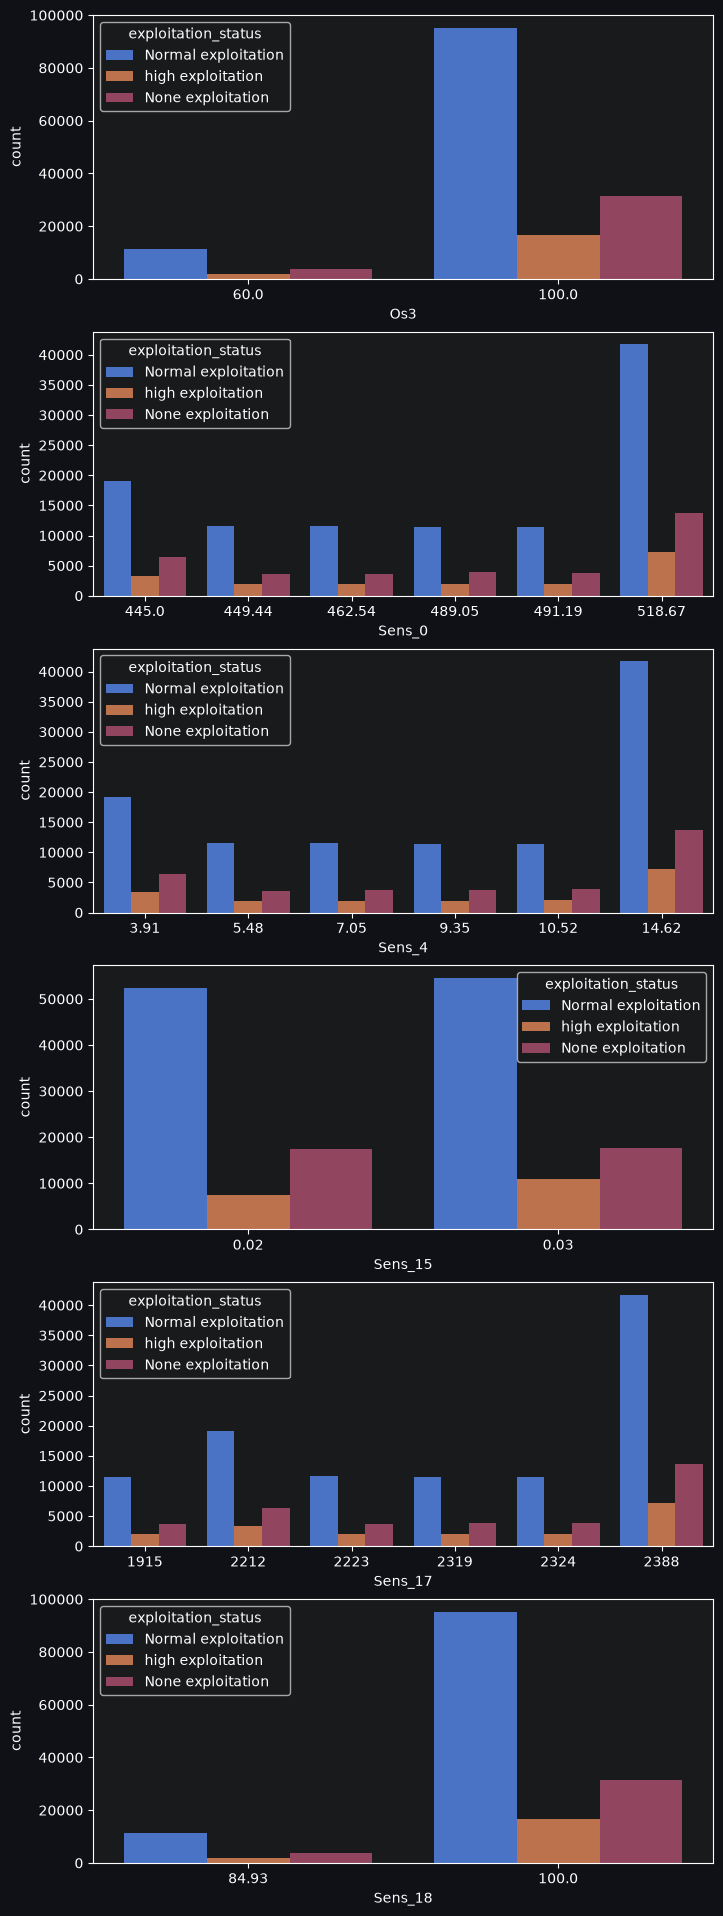

In [18]:
fig, axes = plt.subplots(ncols = 1, nrows = len(cols_to_check), facecolor='#0f1117', figsize=(8, 4*len(cols_to_check)))
for ax, col in zip(axes, cols_to_check):

    sns.countplot(data = df, x = col, ax=ax, hue="exploitation_status")


Because the above features don't represent any singificant/interesting distributions these will be dropped (except for Os3 as it ahs been mentioned as being important with the rest of Os'es).

In [19]:
df = df.drop(["Sens_0", "Sens_4", "Sens_15", "Sens_17", "Sens_18"])

/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


<Axes: xlabel='Sens_5', ylabel='Count'>

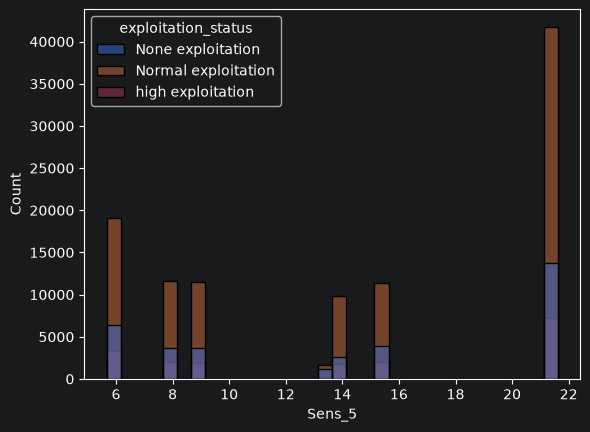

In [20]:
sns.histplot(data = df, x = "Sens_5", hue="exploitation_status")

In [21]:
df.std()

Unit,Cycle,Os1,Os2,Os3,Sens_1,Sens_2,Sens_3,Sens_5,Sens_6,Sens_7,Sens_8,Sens_9,Sens_10,Sens_11,Sens_12,Sens_13,Sens_14,Sens_16,Sens_19,Sens_20,file_path,RUL,exploitation_status
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str
72.867325,83.538146,16.527988,0.367938,12.359044,42.478516,118.175261,136.300073,6.443922,174.133835,142.426613,374.657454,0.142103,3.426342,164.19348,111.167242,80.623257,0.751581,31.02143,11.691422,7.015067,null,83.538146,null


<Axes: >

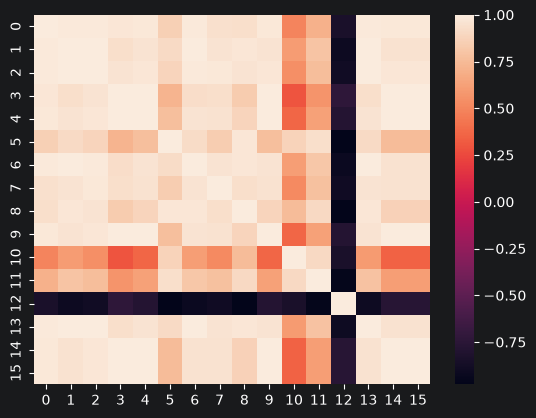

In [22]:
df_heatmap = df[:, "Sens_1":"Sens_20"]
df_heatmap = df_heatmap.corr()
sns.heatmap(data=df_heatmap)

<Axes: >

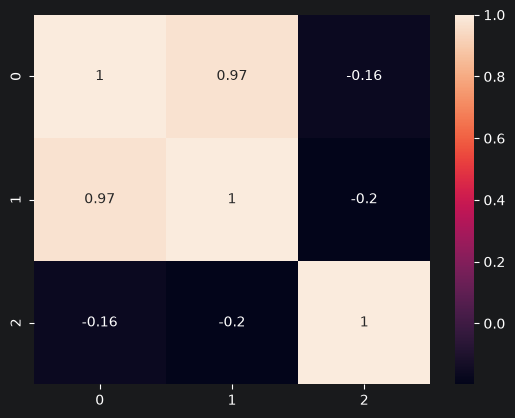

In [23]:
df_heatmap = df[:, "Os1":"Os3"]
df_heatmap = df_heatmap.corr()
sns.heatmap(data=df_heatmap, annot=True)

<Axes: >

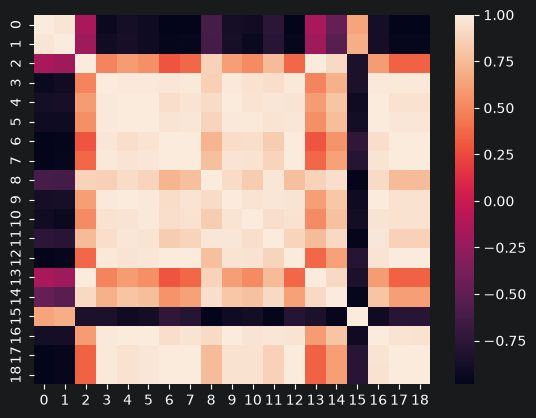

In [24]:
df_heatmap = df[:, "Os1":"Sens_20"]
df_heatmap = df_heatmap.corr()
sns.heatmap(data=df_heatmap)

<Axes: >

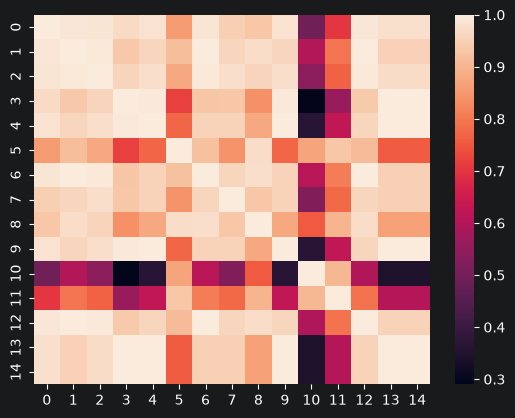

In [25]:
df_heatmap = df[:, "Sens_1":"Sens_20"].drop("Sens_14")
df_heatmap = df_heatmap.corr()
sns.heatmap(data=df_heatmap)

In [26]:
df = df.drop("Sens_14")

<Axes: >

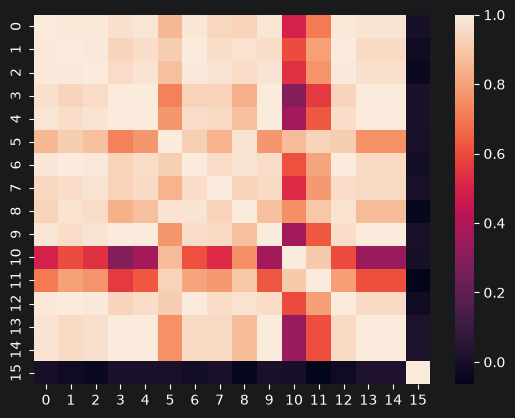

In [27]:
df_heatmap = df[:, "Sens_1":"RUL"].drop("file_path")
df_heatmap = df_heatmap.corr()
sns.heatmap(data=df_heatmap)

<Axes: >

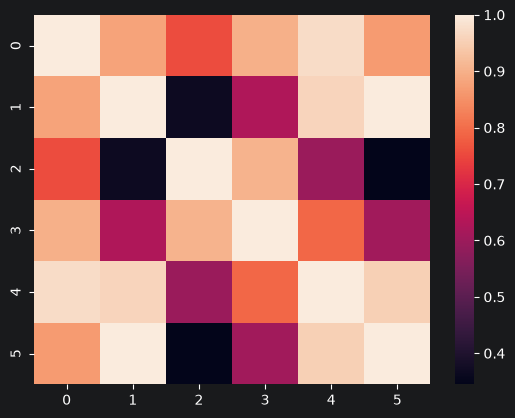

In [28]:
df_heatmap = df[:, "Sens_1":"Sens_20"].drop([ "Sens_1","Sens_2","Sens_3", "Sens_5", "Sens_6", "Sens_7", "Sens_8", "Sens_9", "Sens_20"])
df_heatmap = df_heatmap.corr()
sns.heatmap(data=df_heatmap)

In [29]:
df_heatmap

Sens_10,Sens_11,Sens_12,Sens_13,Sens_16,Sens_19
f64,f64,f64,f64,f64,f64
1.0,0.879072,0.754391,0.89975,0.972795,0.866667
0.879072,1.0,0.366703,0.626968,0.960121,0.999479
0.754391,0.366703,1.0,0.904572,0.598094,0.344837
0.89975,0.626968,0.904572,1.0,0.790664,0.607376
0.972795,0.960121,0.598094,0.790664,1.0,0.95347
0.866667,0.999479,0.344837,0.607376,0.95347,1.0


In [30]:
df = df.drop(["Sens_1","Sens_2","Sens_3", "Sens_5", "Sens_6", "Sens_7","Sens_8", "Sens_9", "Sens_20"])

In [31]:
df.head()

Unit,Cycle,Os1,Os2,Os3,Sens_10,Sens_11,Sens_12,Sens_13,Sens_16,Sens_19,file_path,RUL,exploitation_status
i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,f64,str,i64,str
1,1,-0.0007,-0.0004,100.0,47.47,521.66,2388.02,8138.62,392,39.06,"""../CMAPSSData/train_FD001.txt""",191,"""None exploitation"""
1,2,0.0019,-0.0003,100.0,47.49,522.28,2388.07,8131.49,392,39.0,"""../CMAPSSData/train_FD001.txt""",190,"""None exploitation"""
1,3,-0.0043,0.0003,100.0,47.27,522.42,2388.03,8133.23,390,38.95,"""../CMAPSSData/train_FD001.txt""",189,"""None exploitation"""
1,4,0.0007,0.0,100.0,47.13,522.86,2388.08,8133.83,392,38.88,"""../CMAPSSData/train_FD001.txt""",188,"""None exploitation"""
1,5,-0.0019,-0.0002,100.0,47.28,522.19,2388.04,8133.8,393,38.9,"""../CMAPSSData/train_FD001.txt""",187,"""None exploitation"""


In [32]:
df.columns

['Unit',
 'Cycle',
 'Os1',
 'Os2',
 'Os3',
 'Sens_10',
 'Sens_11',
 'Sens_12',
 'Sens_13',
 'Sens_16',
 'Sens_19',
 'file_path',
 'RUL',
 'exploitation_status']

In [33]:
def training_dataloader(df, feature_cols, window):
    X, y = [], []
    for _, group_df in df.group_by(["file_path", "Unit"]):
        group_df = group_df.sort("Cycle", descending = True)
        data = group_df[feature_cols].to_numpy()
        labels = group_df["RUL"].to_numpy()
        # print(data.shape, labels.shape)
        for i in range(len(group_df)-window+1):
            X.append(data[i:i+window])
            y.append(labels[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

#use last window per engine for test inference
def test_dataloader(df, labels, feature_cols, window):
    X, y = [], []
    for i, (_, group_df) in enumerate(df.group_by(["file_path", "Unit"])):
        group_df  = group_df.sort("Cycle", descending = True)
        data = group_df[feature_cols].to_numpy()
        if len(data) >= window:
            X.append(data[-window:])
        else:
            #pad shorter seq
            pad = np.zeros((window - len(data), len(feature_cols)))
            X.append(np.vstack([pad, data]))
        y.append(labels[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)



In [34]:
for _, group_df in df.group_by(["file_path", "Unit"]):
    print(len(group_df))

163
207
234
240
181
288
280
184
177
370
190
194
172
275
279
361
158
249
246
272
254
243
267
148
150
378
344
283
214
226
201
205
191
239
200
191
193
289
190
170
234
294
200
231
231
180
218
151
185
247
309
257
237
197
481
200
136
259
279
154
197
288
263
158
289
266
202
178
299
302
166
189
178
248
205
207
174
276
209
351
215
308
331
190
154
227
298
208
184
273
259
200
202
275
229
209
194
220
229
188
181
202
149
207
205
184
161
202
224
370
236
297
167
378
303
193
234
202
145
256
245
174
235
222
180
198
221
259
159
203
188
150
321
303
324
262
181
338
213
177
281
494
187
183
209
211
459
202
258
149
380
491
231
184
191
180
193
198
163
239
221
174
184
277
235
206
217
271
197
221
226
212
161
170
154
156
307
185
170
298
220
187
392
192
186
272
208
170
166
219
418
177
183
201
247
177
201
190
174
321
203
303
145
241
525
154
269
250
194
266
188
196
192
194
168
166
221
270
222
156
259
226
200
196
322
297
195
193
255
165
161
324
340
207
234
195
156
146
297
171
221
435
172
218
197
253
446
199
213
297


In [35]:
test_df = pl.scan_csv(
    f"../CMAPSSData/test_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    new_columns=COLS,
    include_file_paths="file_path"
 ).drop(["column_27", "column_28"])

test_df = test_df.collect()

test_labels = pl.read_csv(
    f"../CMAPSSData/RUL_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,

 ).select(pl.nth(range(1)))

test_df.shape, test_labels.shape

((104897, 27), (707, 1))

In [36]:
test_df

Unit,Cycle,Os1,Os2,Os3,Sens_0,Sens_1,Sens_2,Sens_3,Sens_4,Sens_5,Sens_6,Sens_7,Sens_8,Sens_9,Sens_10,Sens_11,Sens_12,Sens_13,Sens_14,Sens_15,Sens_16,Sens_17,Sens_18,Sens_19,Sens_20,file_path
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,str
1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.9,2388.04,9050.17,1.3,47.2,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,"""../CMAPSSData/test_FD001.txt"""
1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.5,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,"""../CMAPSSData/test_FD001.txt"""
1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.5,521.97,2388.03,8130.1,8.4441,0.03,393,2388,100.0,39.08,23.4166,"""../CMAPSSData/test_FD001.txt"""
1,4,0.0042,0.0,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.9,8.3917,0.03,391,2388,100.0,39.0,23.3737,"""../CMAPSSData/test_FD001.txt"""
1,5,0.0014,0.0,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.413,"""../CMAPSSData/test_FD001.txt"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
248,277,41.9991,0.8401,100.0,445.0,550.3,1364.4,1129.17,3.91,5.72,138.34,2212.35,8351.73,1.02,42.3,130.87,2388.5,8112.61,9.4427,0.02,331,2212,100.0,10.53,6.262,"""../CMAPSSData/test_FD004.txt"""
248,278,20.0026,0.7005,100.0,491.19,608.0,1494.75,1260.88,9.35,13.66,334.75,2324.23,8758.69,1.07,44.53,314.51,2388.33,8086.83,9.2772,0.02,366,2324,100.0,24.33,14.6486,"""../CMAPSSData/test_FD004.txt"""
248,279,34.9988,0.8413,100.0,449.44,555.92,1370.65,1130.97,5.48,8.0,194.92,2223.57,8370.49,1.02,42.33,182.76,2388.64,8100.84,9.3982,0.02,336,2223,100.0,14.69,8.8389,"""../CMAPSSData/test_FD004.txt"""


In [37]:
test_labels = test_labels.to_numpy()

In [38]:
FEATURES = [
 'Cycle',
 'Os1',
 'Os2',
 'Os3',
 'Sens_10',
 'Sens_11',
 'Sens_12',
 'Sens_13',
 'Sens_16',
 'Sens_19',]
X_train, y_train = training_dataloader(df, FEATURES, window=32)

In [39]:
X_test, y_test = test_dataloader(test_df, test_labels, FEATURES, window=32)

In [40]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((138380, 32, 10), (138380,), (707, 32, 10), (707, 1))

In [41]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
y_train = y_train.ravel()
y_test = y_test.ravel()

In [42]:
xgb_gpu_pipeline = Pipeline([
    ('xgboost_reg', XGBRegressor(
        device='cuda',                 # Włącza obliczenia na karcie NVIDIA GPU
        n_estimators=100,
        learning_rate=0.1
    ))
])

# Trenowanie modelu – obliczenia XGBoost wykonają się na GPU
xgb_gpu_pipeline.fit(X_train, y_train)

# Przewidywanie wyników (ciągłych liczb)
predictions = xgb_gpu_pipeline.predict(X_test)

/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/xgboost/core.py:553: UserWarning: [18:23:04] WARNING: /home/task_P4w8D_krQ3SsH_0/croot/xgboost-split_1783526132022/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


/tmp/ipykernel_12019/2570207469.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


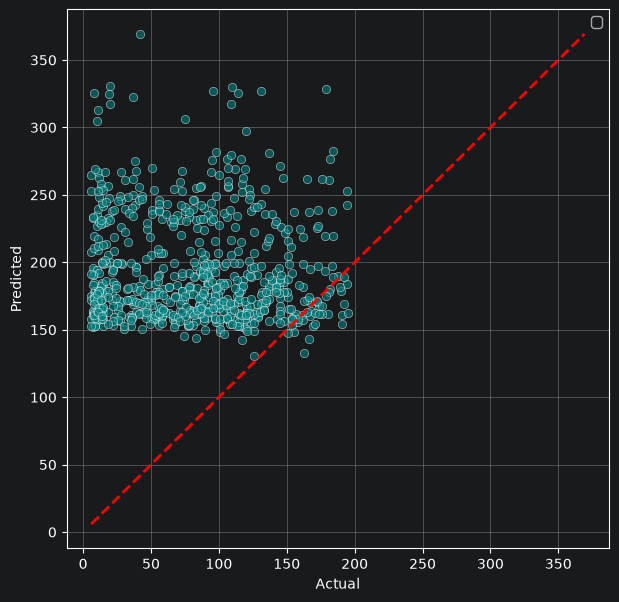

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generujemy przewidywania z Twojego potoku (pipeline)
y_pred = xgb_gpu_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
# Rysujemy punkty danych
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')

# Rysujemy linię idealnego dopasowania (y = x)
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid(True)
plt.show()

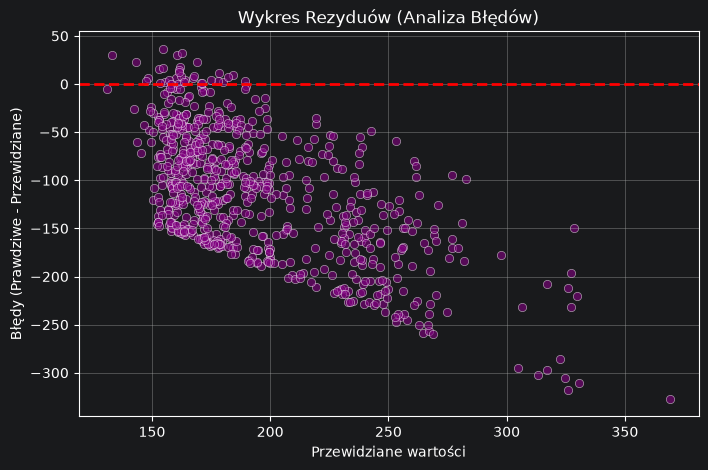

In [44]:
# Obliczamy błędy (rezydua)
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
# Rysujemy punkty błędów wokół linii zero
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', lw=2)

plt.xlabel('Przewidziane wartości')
plt.ylabel('Błędy (Prawdziwe - Przewidziane)')
plt.title('Wykres Rezyduów (Analiza Błędów)')
plt.grid(True)
plt.show()

# Terrible results
1. Check the target distribution in test labels
2. Change the input data fed into the model (aggregation, few epochs different shifts and tiem intervals)

In [45]:
test_label = pl.read_csv(
    f"../CMAPSSData/RUL_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,

 ).select(pl.nth(range(1)))

/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


<Axes: xlabel='column_1', ylabel='Count'>

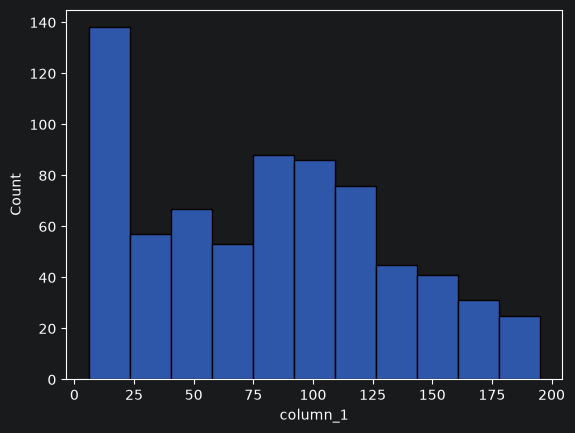

In [46]:
sns.histplot(data=test_label, x="column_1")


looking at the result I am opting setting up the upper limit for RUL

In [47]:
test_label = test_label.with_columns(
    pl.when(pl.col("column_1") >= 150)
    .then(pl.lit(150))
    .otherwise(pl.col("column_1"))
    .alias("column_1")
)

/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


<Axes: xlabel='column_1', ylabel='Count'>

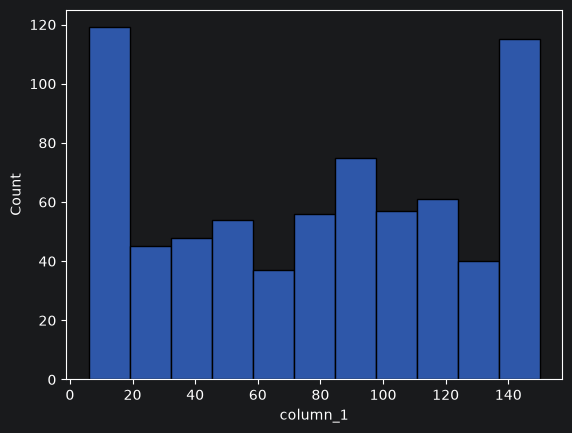

In [48]:
sns.histplot(data=test_label, x="column_1")


# Repeat visualization
as It might have turned out i  have set up the wrong boundries therefore it would be a good idea now to check the previous visualizations conceringn the low number of unique values in some features


In [49]:
#re read the trainign data s asome of the coulmns were deleted
lazy_df = pl.scan_csv(
    f"../CMAPSSData/train_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    new_columns=COLS,
    include_file_paths="file_path"
)
processed_lazy_df = lazy_df.with_columns(  #Calculating target variable for all training data
    (pl.col("Cycle").max().over(["file_path", "Unit"]) - pl.col("Cycle")).alias("RUL")
).drop(["column_27", "column_28"])  #"file_path"

df = processed_lazy_df.collect()

lower_bound = math.ceil(140*0.1)
upper_bound = math.ceil(140*0.9)

df = df.with_columns(
    pl.when(pl.col("RUL") < lower_bound)
    .then(pl.lit("high exploitation"))
    .when(pl.col("RUL") > upper_bound)
    .then(pl.lit("None exploitation"))
    .otherwise(pl.lit("Normal exploitation"))
    .alias("exploitation_status")
)

/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow

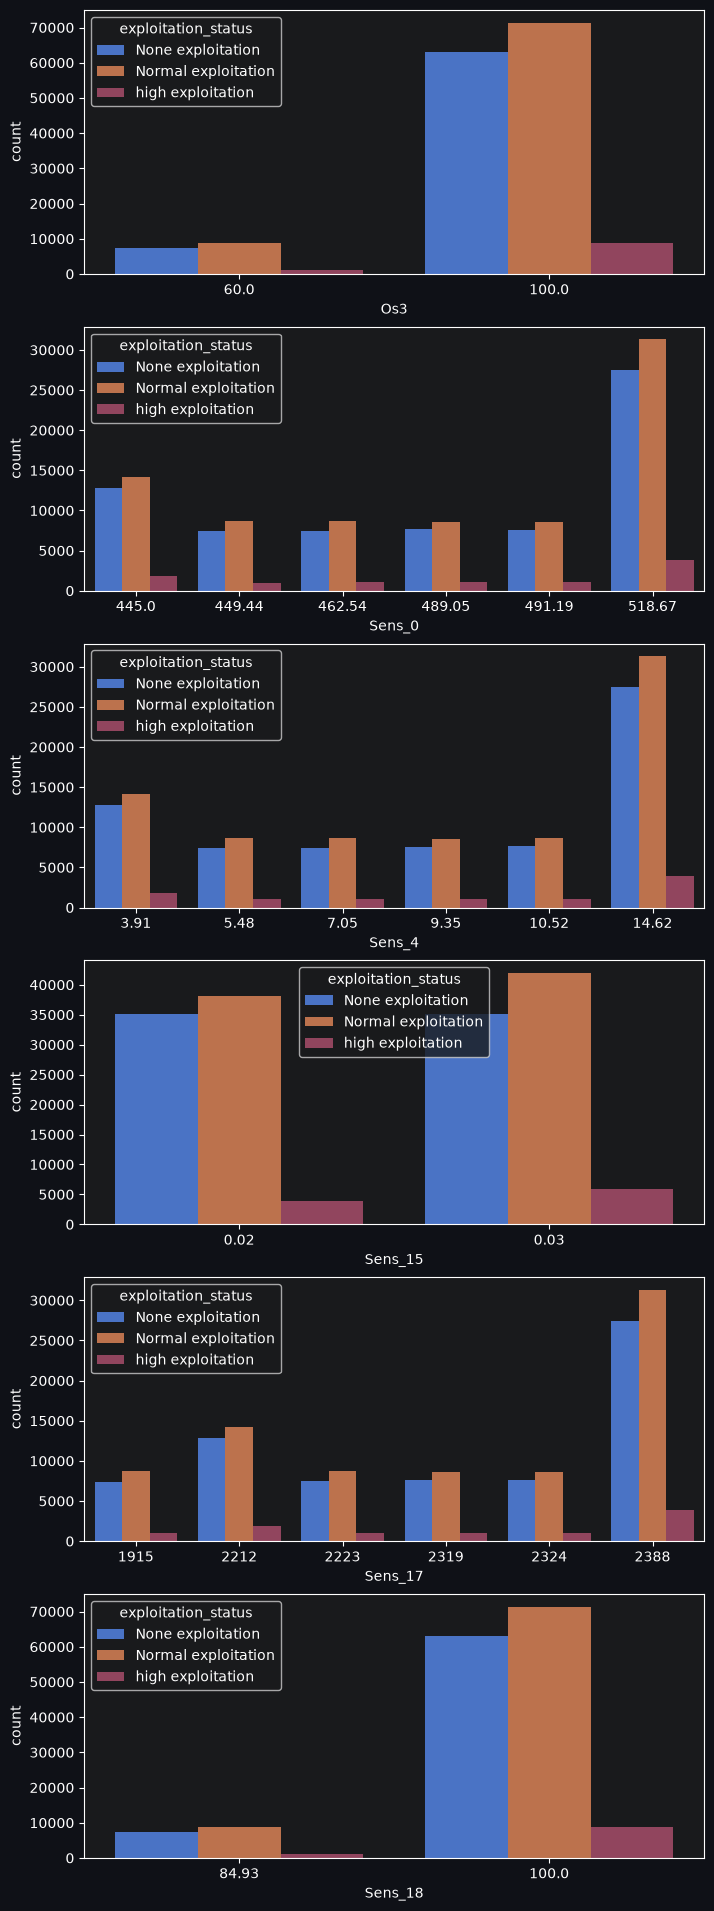

In [50]:
cols_to_check = ["Os3", "Sens_0", "Sens_4", "Sens_15", "Sens_17", "Sens_18"]
fig, axes = plt.subplots(ncols=1, nrows=len(cols_to_check), facecolor='#0f1117', figsize=(8, 4 * len(cols_to_check)))
for ax, col in zip(axes, cols_to_check):
    sns.countplot(data=df, x=col, ax=ax, hue="exploitation_status")

IT looks like all of the features still follow the same distribution therefore due to thier low variance I will delete them again

In [51]:
df = df.drop(["Sens_0", "Sens_4", "Sens_15", "Sens_17", "Sens_18"])

Because other features are correlated to each other in the same way I will take adnvantage of previou sknowledge and delete highly correlated Features

In [52]:
df = df.drop(["Sens_1","Sens_2","Sens_3", "Sens_5", "Sens_6", "Sens_7","Sens_8", "Sens_9", "Sens_20"])

# 2. Input processing
This time input data won't be raw but rather split into epochs and aggregated.
Epochs split:
1) 7 cycles
2) 7 cycles before the target cycle (split 1)
3) Concatenated cycles from epochs split 1 and 2
4) 7 cycles before the split 2
5) split 1,2 and 4 concatented to each other <br>
I belive this split will give enough information at the time of prediction (about 7 cycles), as well as enough comparision for previous windows and influence on each other for bigger windows

In [53]:
import scipy
def aggregate_epoch(epoch):
    """
    Extract aggregated values of each feature from windows length of data.

    :param epoch: (np.ndarray): 2D array (num_examples, window_length, feature)
            - window_length: the length of observation belonging to the given epoch split
            - feature: TO which feature the values belong to (length fo this tensor is equal length of columns used as input)

    :return:
        np.ndarray: 1D array (num_examples, epoch, aggregated_features)
            - aggregated_features: feature * 5 (number of aggregated values to be returned)
    """

    #We are aggregating of each feature in windows length
    std = np.std(epoch, axis=-2)
    iqr = scipy.stats.iqr(epoch, axis=-2, nan_policy="propagate")
    high_percentile = np.percentile(epoch, 97, axis=-2)
    low_percentile = np.percentile(epoch, 3, axis=-2)
    mean = np.mean(epoch, axis=-2)
    # skewness = skew(epoch, axis = -2)
    # kurtosis_of_data = kurtosis(epoch, axis = -2)

    aggregated_features = np.stack([std, iqr, high_percentile, low_percentile, mean], axis=-1) # skewness, kurtosis_of_data
    # print(aggregated_features.shape)
    # x, _ = aggregated_features.shape
    # print(aggregated_features.shape)
    return aggregated_features.reshape(1, -1)


In [54]:
def training_dataloader(df, feature_cols, window=7):
    """

    :param df: DataFrame to be transfer into numpy array
    :param feature_cols: Columns from given DataFrame to be used
    :param window: Number of Cycles to be included in a given epoch
    :return:
            np.ndarray: 2D array (num_examples, input features)
            - num_examples: Number of examples
            - input features: number of aggregated features (same as number of returned features in aggregate_epoch funtion) * number of differnet epochs (currently 5)
    """

    X, y = [], []
    for _, group_df in df.group_by(["file_path", "Unit"]):
        group_df = group_df.sort("Cycle", descending = True)
        data = group_df[feature_cols].to_numpy()
        labels = group_df["RUL"].to_numpy()
        # print(data.shape, labels.shape)
        for i in range(3*window,len(group_df)):
            split_1 = aggregate_epoch(data[i-window+1:i+1])
            split_2 = aggregate_epoch(data[i-2*window+1:i-window+1])
            split_3 = aggregate_epoch(data[i-2*window+1:i+1])
            split_4 = aggregate_epoch(data[i-3*window+1:i-2*window+1])
            split_5 = aggregate_epoch(data[i-3*window+1:i+1])
            X.append(np.concat((split_1, split_2, split_3, split_4, split_5)).ravel())
            # print(data[i-window+1:i+1].shape, split_1.shape, np.concat((split_1, split_2, split_3, split_4, split_5)).ravel().shape)
            y.append(labels[i]) #left unchanged

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

#use last window per engine for test inference
def test_dataloader(df, labels, feature_cols, window):
    X, y = [], []
    for i, (_, group_df) in enumerate(df.group_by(["file_path", "Unit"])):
        group_df  = group_df.sort("Cycle", descending = True)
        data = group_df[feature_cols].to_numpy()
        last_value = len(data)
        # print(data.shape)
        # X.append(data[-window:])
        split_1 = aggregate_epoch(data[last_value-window+1:last_value+1])
        split_2 = aggregate_epoch(data[last_value-2*window+1:last_value-window+1])
        split_3 = aggregate_epoch(data[last_value-2*window+1:last_value+1])
        split_4 = aggregate_epoch(data[last_value-3*window+1:last_value-2*window+1])
        split_5 = aggregate_epoch(data[last_value-3*window+1:last_value+1])
        X.append(np.concat((split_1, split_2, split_3, split_4, split_5)).ravel())
        y.append(labels[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [55]:
FEATURES = [
    'Cycle',
    'Os1',
    'Os2',
    'Os3',
    'Sens_10',
    'Sens_11',
    'Sens_12',
    'Sens_13',
    'Sens_16',
    'Sens_19', ]
X_train, y_train = training_dataloader(df, FEATURES, window=6)#6 is the biggest possible number due to the test file

In [56]:
np.save("X_train", X_train)
np.save("y_train", y_train)

In [57]:
test_df = pl.scan_csv(
    f"../CMAPSSData/test_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    new_columns=COLS,
    include_file_paths="file_path"
 ).drop(["column_27", "column_28"])

test_df = test_df.collect()

test_labels = (
    pl.read_csv(
        f"../CMAPSSData/RUL_FD00*.txt",
        separator=" ",
        truncate_ragged_lines=True,
        has_header=False,
    )
    .select(pl.nth(0).clip(upper_bound=140))  # Caps any value >= 140 at 140
)

In [58]:
print(test_df.shape, test_label.shape)
X_test, y_test = test_dataloader(test_df, test_labels, FEATURES, window=6)#6 is the biggest possible number due to the test file


(104897, 27) (707, 1)


In [59]:
y_test = y_test.ravel()
y_train = y_train.ravel()
print(X_test.shape, y_test.shape,X_train.shape, y_train.shape)

(707, 250) (707,) (147597, 250) (147597,)


In [67]:

xgb_gpu_pipeline = Pipeline([
    ('xgboost_reg', XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    eval_metric='rmse',
    random_state=42,
    device='cuda'   # if GPU available
))
])

# Trenowanie modelu – obliczenia XGBoost wykonają się na GPU
xgb_gpu_pipeline.fit(X_train, y_train)

# Przewidywanie wyników (ciągłych liczb)
predictions = xgb_gpu_pipeline.predict(X_test)

In [68]:
y_test.shape

(707,)

/tmp/ipykernel_12019/465785177.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


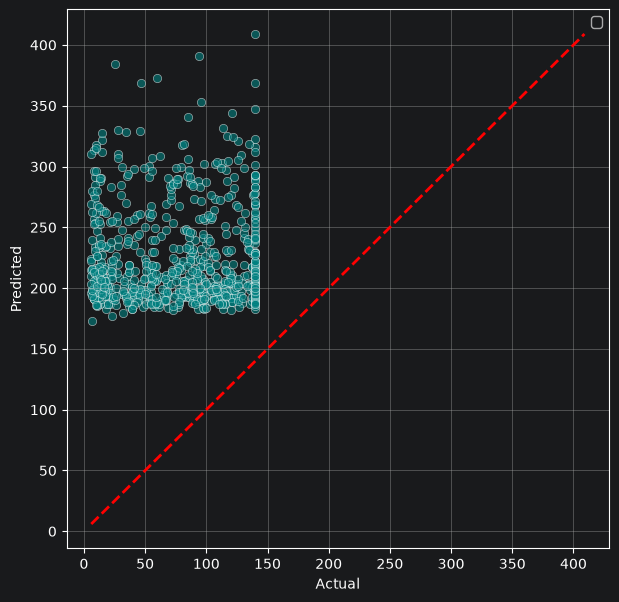

In [69]:
# Generujemy przewidywania z Twojego potoku (pipeline)
y_pred = xgb_gpu_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
# Rysujemy punkty danych
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')

# Rysujemy linię idealnego dopasowania (y = x)
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid(True)
plt.show()

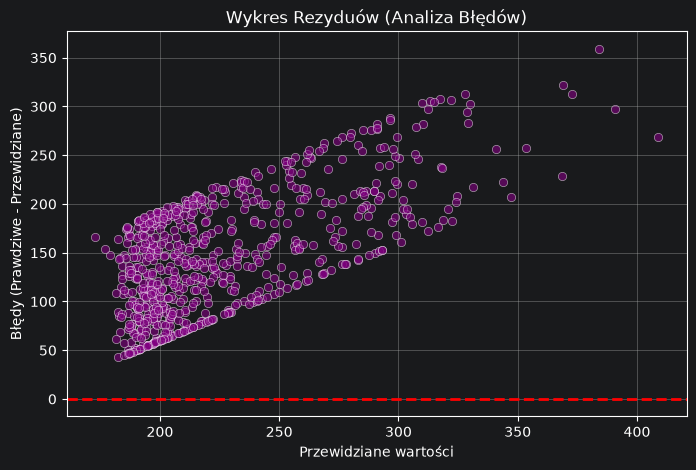

In [70]:
# Obliczamy błędy (rezydua)
residuals = abs(y_test - y_pred)

plt.figure(figsize=(8, 5))
# Rysujemy punkty błędów wokół linii zero
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', lw=2)

plt.xlabel('Przewidziane wartości')
plt.ylabel('Błędy (Prawdziwe - Przewidziane)')
plt.title('Wykres Rezyduów (Analiza Błędów)')
plt.grid(True)
plt.show()

In [71]:
y_test.shape, y_pred.shape

((707,), (707,))

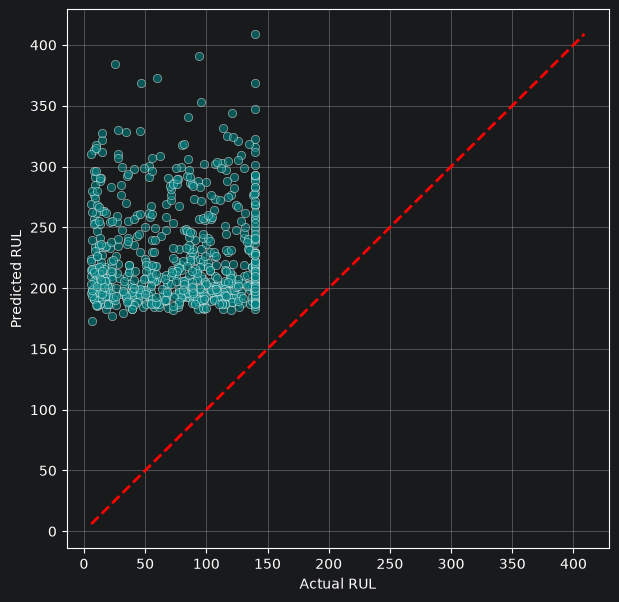

In [72]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.grid(True)
plt.show()